# **Applied Machine Learning for Cyber Security**

## **Notebook 4: Modeling with Manual Downsampling of the Benign Class**

This notebook is part of the HELLO_FLOOD attack detection project. It explores an alternative strategy for handling class imbalance by **manually downsampling the benign class (majority)** to match the size of the malicious class (minority). This approach allows us to evaluate model performance on a dataset that is balanced using **real data only**, without introducing synthetic samples.

Manual downsampling ensures that all data used for training and testing is real, helping to test model accuracy and generalization under realistic conditions.

---

### **Covered in this notebook:**
- Preprocessing and cleaning of the HELLO_FLOOD dataset  
- Label encoding and feature scaling  
- **Manual downsampling of the benign class to match malicious class count**  
- Stratified train-test split (70/30) after downsampling  
- Implementation and evaluation of the following models:
  - Logistic Regression  
  - Random Forest Classifier  
  - Multi-Layer Perceptron (Neural Network)  
  - LSTM using PyTorch  
  - GRU using PyTorch  
- Evaluation metrics: Accuracy, Precision, Recall, F1 Score  
- Confusion matrix visualizations and random prediction samples  
- **Unsupervised anomaly detection using Isolation Forest**  
- Model performance comparison (table, bar plot, F1 slope graph)
---
This notebook complements previous approaches by analyzing how **real-data-only balancing** impacts model performance, especially in contrast to synthetic resampling (SMOTE).


### **1. Importing Neccessary Libraries**

In [113]:
# Libraries for DataModeling and Visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import warnings

# For Preprocessing Step
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# For Model Selection and Evaluation
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from rich.console import Console
from tabulate import tabulate
import pickle

In [114]:
# Initialize console for pretty printing
console = Console()
warnings.filterwarnings("ignore", category=UserWarning, module='statsmodels')

### **2. Preprocessing**

#### **2.1 Loading Dataset**

In [115]:
# Load the dataset
file_path = "Hello_Flood.csv"
df = pd.read_csv(file_path)

# Display the first 10 rows to understand the structure of the dataset
console.print(f"[bold]First 10 rows of the dataset:[/bold]")
df.head()

First 10 rows of the dataset:

,PACKET_ID,SEGMENT_ID,PACKET_TYPE,CONTROL_PACKET_TYPE/APP_NAME,SOURCE_ID,DESTINATION_ID,TRANSMITTER_ID,RECEIVER_ID,APP_LAYER_ARRIVAL_TIME(US),TRX_LAYER_ARRIVAL_TIME(US),...,isFin,SEGMENT_LEN,SOURCE_IP,DESTINATION_IP,GATEWAY_IP,NEXT_HOP_IP,PCKT_LABEL,RPL_RANK,RPL_VERSION,Unnamed: 38
0,0,0.0,Control_Packet,OSPF_HELLO,SINKNODE-17,Broadcast-0,SINKNODE-17,ROUTER-18,0.0,0.0,...,NaN,NaN,11.3.1.2,224.0.0.5,11.3.1.2,224.0.0.5,0,NaN,NaN,NaN
1,0,0.0,Control_Packet,OSPF_HELLO,ROUTER-18,Broadcast-0,ROUTER-18,SINKNODE-17,0.0,0.0,...,NaN,NaN,11.3.1.1,224.0.0.5,11.3.1.1,224.0.0.5,0,NaN,NaN,NaN
2,0,NaN,Control_Packet,DIO,SINKNODE-17,Broadcast-0,SINKNODE-17,SENSOR-5,NaN,NaN,...,NaN,NaN,FDEC:3017:E256:9BB8:1FE7:DF79:8803:32DB,FF00:0:0:0:0:0:0:0,FDEC:3017:E256:9BB8:1FE7:DF79:8803:32DB,FF00:0:0:0:0:0:0:0,0,1.0,0.0,NaN
3,0,NaN,Control_Packet,DIO,SINKNODE-17,Broadcast-0,SINKNODE-17,SENSOR-8,NaN,NaN,...,NaN,NaN,FDEC:3017:E256:9BB8:1FE7:DF79:8803:32DB,FF00:0:0:0:0:0:0:0,FDEC:3017:E256:9BB8:1FE7:DF79:8803:32DB,FF00:0:0:0:0:0:0:0,0,1.0,0.0,NaN
4,0,NaN,Control_Packet,DIO,SINKNODE-17,Broadcast-0,SINKNODE-17,SENSOR-10,NaN,NaN,...,NaN,NaN,FDEC:3017:E256:9BB8:1FE7:DF79:8803:32DB,FF00:0:0:0:0:0:0:0,FDEC:3017:E256:9BB8:1FE7:DF79:8803:32DB,FF00:0:0:0:0:0:0:0,0,1.0,0.0,NaN


#### **2.2 Basic Information of the Dataset**

##### **2.2.1 Size of the Dataset**

In [116]:
rows, cols = df.shape
console.print(f"[bold yellow]Dataset Dimensions:[/bold yellow] {rows} rows × {cols} columns")

Dataset Dimensions: 897680 rows × 39 columns

##### **2.2.2 Head and Tail of the Dataset**

In [117]:
# Display the First 05 rows to understand the structure of the dataset
console.print(f"[bold]First 05 rows of the Dataset:[/bold]")
df.head()

First 05 rows of the Dataset:

,PACKET_ID,SEGMENT_ID,PACKET_TYPE,CONTROL_PACKET_TYPE/APP_NAME,SOURCE_ID,DESTINATION_ID,TRANSMITTER_ID,RECEIVER_ID,APP_LAYER_ARRIVAL_TIME(US),TRX_LAYER_ARRIVAL_TIME(US),...,isFin,SEGMENT_LEN,SOURCE_IP,DESTINATION_IP,GATEWAY_IP,NEXT_HOP_IP,PCKT_LABEL,RPL_RANK,RPL_VERSION,Unnamed: 38
0,0,0.0,Control_Packet,OSPF_HELLO,SINKNODE-17,Broadcast-0,SINKNODE-17,ROUTER-18,0.0,0.0,...,NaN,NaN,11.3.1.2,224.0.0.5,11.3.1.2,224.0.0.5,0,NaN,NaN,NaN
1,0,0.0,Control_Packet,OSPF_HELLO,ROUTER-18,Broadcast-0,ROUTER-18,SINKNODE-17,0.0,0.0,...,NaN,NaN,11.3.1.1,224.0.0.5,11.3.1.1,224.0.0.5,0,NaN,NaN,NaN
2,0,NaN,Control_Packet,DIO,SINKNODE-17,Broadcast-0,SINKNODE-17,SENSOR-5,NaN,NaN,...,NaN,NaN,FDEC:3017:E256:9BB8:1FE7:DF79:8803:32DB,FF00:0:0:0:0:0:0:0,FDEC:3017:E256:9BB8:1FE7:DF79:8803:32DB,FF00:0:0:0:0:0:0:0,0,1.0,0.0,NaN
3,0,NaN,Control_Packet,DIO,SINKNODE-17,Broadcast-0,SINKNODE-17,SENSOR-8,NaN,NaN,...,NaN,NaN,FDEC:3017:E256:9BB8:1FE7:DF79:8803:32DB,FF00:0:0:0:0:0:0:0,FDEC:3017:E256:9BB8:1FE7:DF79:8803:32DB,FF00:0:0:0:0:0:0:0,0,1.0,0.0,NaN
4,0,NaN,Control_Packet,DIO,SINKNODE-17,Broadcast-0,SINKNODE-17,SENSOR-10,NaN,NaN,...,NaN,NaN,FDEC:3017:E256:9BB8:1FE7:DF79:8803:32DB,FF00:0:0:0:0:0:0:0,FDEC:3017:E256:9BB8:1FE7:DF79:8803:32DB,FF00:0:0:0:0:0:0:0,0,1.0,0.0,NaN


In [118]:
# Display the last 05 rows to understand the structure of the dataset
console.print(f"[bold]Last 05 rows of the Dataset:[/bold]")
df.tail()

Last 05 rows of the Dataset:

,PACKET_ID,SEGMENT_ID,PACKET_TYPE,CONTROL_PACKET_TYPE/APP_NAME,SOURCE_ID,DESTINATION_ID,TRANSMITTER_ID,RECEIVER_ID,APP_LAYER_ARRIVAL_TIME(US),TRX_LAYER_ARRIVAL_TIME(US),...,isFin,SEGMENT_LEN,SOURCE_IP,DESTINATION_IP,GATEWAY_IP,NEXT_HOP_IP,PCKT_LABEL,RPL_RANK,RPL_VERSION,Unnamed: 38
897675,0,NaN,Control_Packet,DIO,SENSOR-5,Broadcast-0,SENSOR-5,SENSOR-10,NaN,NaN,...,NaN,NaN,FDEC:3017:E256:9BB8:1FE7:7F3D:960A:1BCB,FF00:0:0:0:0:0:0:0,FDEC:3017:E256:9BB8:1FE7:7F3D:960A:1BCB,FF00:0:0:0:0:0:0:0,1,15.0,0.0,NaN
897676,0,NaN,Control_Packet,DIO,SENSOR-5,Broadcast-0,SENSOR-5,SENSOR-14,NaN,NaN,...,NaN,NaN,FDEC:3017:E256:9BB8:1FE7:7F3D:960A:1BCB,FF00:0:0:0:0:0:0:0,FDEC:3017:E256:9BB8:1FE7:7F3D:960A:1BCB,FF00:0:0:0:0:0:0:0,1,15.0,0.0,NaN
897677,0,NaN,Control_Packet,DIO,SENSOR-5,Broadcast-0,SENSOR-5,SENSOR-16,NaN,NaN,...,NaN,NaN,FDEC:3017:E256:9BB8:1FE7:7F3D:960A:1BCB,FF00:0:0:0:0:0:0:0,FDEC:3017:E256:9BB8:1FE7:7F3D:960A:1BCB,FF00:0:0:0:0:0:0:0,1,15.0,0.0,NaN
897678,0,NaN,Control_Packet,DIO,SENSOR-5,Broadcast-0,SENSOR-5,SINKNODE-17,NaN,NaN,...,NaN,NaN,FDEC:3017:E256:9BB8:1FE7:7F3D:960A:1BCB,FF00:0:0:0:0:0:0:0,FDEC:3017:E256:9BB8:1FE7:7F3D:960A:1BCB,FF00:0:0:0:0:0:0:0,1,15.0,0.0,NaN
897679,0,NaN,Control_Packet,DIO,SENSOR-5,Broadcast-0,SENSOR-5,SENSOR-1,NaN,NaN,...,NaN,NaN,FDEC:3017:E256:9BB8:1FE7:7F3D:960A:1BCB,FF00:0:0:0:0:0:0:0,FDEC:3017:E256:9BB8:1FE7:7F3D:960A:1BCB,FF00:0:0:0:0:0:0:0,1,15.0,0.0,NaN


##### **2.2.3 Types of Attributes (Columns) in the Dataset**

In [119]:
# Prepare data: column names and their data types
dtype_table = [(col, str(dtype)) for col, dtype in df.dtypes.items()]

# Print table with a clear format
console.print("[bold cyan]Data Types of Each Column:[/bold cyan]")
console.print(tabulate(dtype_table, headers=["Column Name", "Data Type"], tablefmt="fancy_grid"))

Data Types of Each Column:

╒══════════════════════════════╤═════════════╕
│ Column Name                  │ Data Type   │
╞══════════════════════════════╪═════════════╡
│ PACKET_ID                    │ int64       │
├──────────────────────────────┼─────────────┤
│ SEGMENT_ID                   │ float64     │
├──────────────────────────────┼─────────────┤
│ PACKET_TYPE                  │ object      │
├──────────────────────────────┼─────────────┤
│ CONTROL_PACKET_TYPE/APP_NAME │ object      │
├──────────────────────────────┼─────────────┤
│ SOURCE_ID                    │ object      │
├──────────────────────────────┼─────────────┤
│ DESTINATION_ID               │ object      │
├──────────────────────────────┼─────────────┤
│ TRANSMITTER_ID               │ object      │
├──────────────────────────────┼─────────────┤
│ RECEIVER_ID                  │ object      │
├──────────────────────────────┼─────────────┤
│ APP_LAYER_ARRIVAL_TIME(US)   │ float64     │
├──────────────────────────────┼─────────────┤
│ TRX_LAYER_ARRIVAL_TIME(US)   │ float64     │
├──────────────────────────────┼─────────────┤
│ NW_LAYER_ARRIVAL_TIME(US)    │ float64     │
├──────────────────────────────┼─────────────┤
│ MAC_LAYER_ARRIVAL_TIME(US)   │ float64     │
├──────────────────────────────┼─────────────┤
│ PHY_LAYER_ARRIVAL_TIME(US)   │ float64     │
├──────────────────────────────┼─────────────┤
│ PHY_LAYER_START_TIME(US)     │ float64     │
├──────────────────────────────┼─────────────┤
│ PHY_LAYER_END_TIME(US)       │ float64     │
├──────────────────────────────┼─────────────┤
│ APP_LAYER_PAYLOAD(Bytes)     │ float64     │
├──────────────────────────────┼─────────────┤
│ TRX_LAYER_PAYLOAD(Bytes)     │ float64     │
├──────────────────────────────┼─────────────┤
│ NW_LAYER_PAYLOAD(Bytes)      │ float64     │
├──────────────────────────────┼─────────────┤
│ MAC_LAYER_PAYLOAD(Bytes)     │ float64     │
├──────────────────────────────┼─────────────┤
│ PHY_LAYER_PAYLOAD(Bytes)     │ float64     │
├──────────────────────────────┼─────────────┤
│ PHY_LAYER_OVERHEAD(Bytes)    │ float64     │
├──────────────────────────────┼─────────────┤
│ PACKET_STATUS                │ object      │
├──────────────────────────────┼─────────────┤
│ LOCAL_ADDRESS                │ float64     │
├──────────────────────────────┼─────────────┤
│ REMOTE_ADDRESS               │ float64     │
├──────────────────────────────┼─────────────┤
│ CWND                         │ float64     │
├──────────────────────────────┼─────────────┤
│ SEQ_NO                       │ float64     │
├──────────────────────────────┼─────────────┤
│ ACK_NO                       │ float64     │
├──────────────────────────────┼─────────────┤
│ isSyn                        │ float64     │
├──────────────────────────────┼─────────────┤
│ isAck                        │ float64     │
├──────────────────────────────┼─────────────┤
│ isFin                        │ float64     │
├──────────────────────────────┼─────────────┤
│ SEGMENT_LEN                  │ float64     │
├──────────────────────────────┼─────────────┤
│ SOURCE_IP                    │ object      │
├──────────────────────────────┼─────────────┤
│ DESTINATION_IP               │ object      │
├──────────────────────────────┼─────────────┤
│ GATEWAY_IP                   │ object      │
├──────────────────────────────┼─────────────┤
│ NEXT_HOP_IP                  │ object      │
├──────────────────────────────┼─────────────┤
│ PCKT_LABEL                   │ int64       │
├──────────────────────────────┼─────────────┤
│ RPL_RANK                     │ float64     │
├──────────────────────────────┼─────────────┤
│ RPL_VERSION                  │ float64     │
├──────────────────────────────┼─────────────┤
│ Unnamed: 38                  │ float64     │
╘══════════════════════════════╧═════════════╛

##### **2.2.4 Total Rows + Columns and Data Type Count in the Dataset**

In [120]:
# Rows + Column count
console.print(f"[bold blue]Total Columns:[/bold blue] {df.shape[1]}",
              f"\n[bold blue]Total Rows   :[/bold blue] {df.shape[0]}")

# Data types count
dtype_counts = df.dtypes.value_counts().reset_index()
dtype_counts.columns = ['Data Type', 'Count']

console.print("[bold blue]Summary of Data Types:[/bold blue]\n" , dtype_counts)

Total Columns: 39 
Total Rows   : 897680

Summary of Data Types:
   Data Type  Count
0   float64     26
1    object     11
2     int64      2

#### **2.3 Handling Null Values in the Dataset**

##### **2.3.1 Check for Null Values**

In [121]:
console.print("[bold yellow]Null Value Count in Dataset (Top 10):[/bold yellow]")
console.print(df.isnull().sum().sort_values(ascending=False).head(17))

Null Value Count in Dataset (Top 10):

CWND                          897680
SEQ_NO                        897680
ACK_NO                        897680
isSyn                         897680
isAck                         897680
isFin                         897680
LOCAL_ADDRESS                 897680
SEGMENT_LEN                   897680
REMOTE_ADDRESS                897680
Unnamed: 38                   897680
APP_LAYER_PAYLOAD(Bytes)      863743
TRX_LAYER_PAYLOAD(Bytes)      863743
TRX_LAYER_ARRIVAL_TIME(US)    863743
SEGMENT_ID                    863743
APP_LAYER_ARRIVAL_TIME(US)    863743
RPL_RANK                       33937
RPL_VERSION                    33937
dtype: int64

##### **2.3.2 Filter and Print Columns with 100% Missing Values**

In [122]:
full_null_cols = df.columns[df.isnull().sum() == df.shape[0]]
console.print(f"[bold red]Columns with 100% missing values:[/bold red] {list(full_null_cols)}")

Columns with 100% missing values: ['LOCAL_ADDRESS', 'REMOTE_ADDRESS', 'CWND', 'SEQ_NO', 'ACK_NO', 'isSyn', 'isAck',
'isFin', 'SEGMENT_LEN', 'Unnamed: 38']

##### **2.3.3 Drop Columns with 100% Missing Values**

In [123]:
df.drop(columns=full_null_cols, inplace=True)

##### **2.3.4 Drop Columns with High Null Count (>60% nulls)**

In [124]:
threshold = 0.6 * len(df)  # 60% of rows
high_null_cols = df.columns[df.isnull().sum() > threshold]
console.print(f"[bold red]Columns dropped due to >60% missing values:[/bold red] {list(high_null_cols)}")
df.drop(columns=high_null_cols, inplace=True)

Columns dropped due to >60% missing values: ['SEGMENT_ID', 'APP_LAYER_ARRIVAL_TIME(US)', 
'TRX_LAYER_ARRIVAL_TIME(US)', 'APP_LAYER_PAYLOAD(Bytes)', 'TRX_LAYER_PAYLOAD(Bytes)']

##### **2.3.5 Final Null Value Count**

In [125]:
console.print("[bold green]Remaining Null Values per Column:[/bold green]")
console.print(df.isnull().sum()[df.isnull().sum() > 0])

Remaining Null Values per Column:

RPL_RANK       33937
RPL_VERSION    33937
dtype: int64

#### **2.4 Handling Duplicate Values in the Dataset**

##### **2.4.1 Check for Duplicate Values**

In [126]:
duplicate_count = df.duplicated().sum()
console.print(f"[bold yellow]Total Duplicate Rows Found:[/bold yellow] {duplicate_count}")

Total Duplicate Rows Found: 0

##### **2.4.2 Drop Duplicate Values (if any)**

In [127]:
# Drop duplicates if any
if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    console.print("[bold green]Duplicate rows removed.[/bold green]")
else:
    console.print("[bold green]No duplicate rows found.[/bold green]")

No duplicate rows found.

##### **2.4.3 Print new shape**

In [128]:
console.print(f"[bold blue]New Dataset Shape:[/bold blue] {df.shape[0]} rows × {df.shape[1]} columns")

New Dataset Shape: 897680 rows × 24 columns

#### **2.5 Handling Columns as per decided in the proposal**

##### **2.5.1 Drop Columns as per recommendations**

In [129]:
# Drop columns as per proposal recommendations
columns_to_drop = [
    "PACKET_ID",
    "RPL_VERSION",
    "PHY_LAYER_PAYLOAD(Bytes)",
    "PHY_LAYER_OVERHEAD(Bytes)",
    "PACKET_STATUS",
    "NW_LAYER_ARRIVAL_TIME(US)",
    "MAC_LAYER_ARRIVAL_TIME(US)"
]

df.drop(columns=columns_to_drop, inplace=True, errors='ignore')
console.print(f"[bold red]Dropped Columns:[/bold red] {columns_to_drop}")

Dropped Columns: ['PACKET_ID', 'RPL_VERSION', 'PHY_LAYER_PAYLOAD(Bytes)', 'PHY_LAYER_OVERHEAD(Bytes)', 
'PACKET_STATUS', 'NW_LAYER_ARRIVAL_TIME(US)', 'MAC_LAYER_ARRIVAL_TIME(US)']

##### **2.5.2 Print new shape**

In [130]:
console.print(f"[bold green]New Dataset Shape:[/bold green] {df.shape[0]} rows × {df.shape[1]} columns")

New Dataset Shape: 897680 rows × 17 columns

#### **2.6 Categorical Columns in the Dataset**

##### **2.6.1 Identify Categorical Columns**

In [131]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
console.print(f"[bold yellow]Categorical Columns Detected:[/bold yellow] {categorical_cols}")

Categorical Columns Detected: ['PACKET_TYPE', 'CONTROL_PACKET_TYPE/APP_NAME', 'SOURCE_ID', 'DESTINATION_ID', 
'TRANSMITTER_ID', 'RECEIVER_ID', 'SOURCE_IP', 'DESTINATION_IP', 'GATEWAY_IP', 'NEXT_HOP_IP']

In [132]:
df.head()

,PACKET_TYPE,CONTROL_PACKET_TYPE/APP_NAME,SOURCE_ID,DESTINATION_ID,TRANSMITTER_ID,RECEIVER_ID,PHY_LAYER_ARRIVAL_TIME(US),PHY_LAYER_START_TIME(US),PHY_LAYER_END_TIME(US),NW_LAYER_PAYLOAD(Bytes),MAC_LAYER_PAYLOAD(Bytes),SOURCE_IP,DESTINATION_IP,GATEWAY_IP,NEXT_HOP_IP,PCKT_LABEL,RPL_RANK
0,Control_Packet,OSPF_HELLO,SINKNODE-17,Broadcast-0,SINKNODE-17,ROUTER-18,0.0,5.12,10.12,44.0,64.0,11.3.1.2,224.0.0.5,11.3.1.2,224.0.0.5,0,NaN
1,Control_Packet,OSPF_HELLO,ROUTER-18,Broadcast-0,ROUTER-18,SINKNODE-17,0.0,5.12,10.12,44.0,64.0,11.3.1.1,224.0.0.5,11.3.1.1,224.0.0.5,0,NaN
2,Control_Packet,DIO,SINKNODE-17,Broadcast-0,SINKNODE-17,SENSOR-5,6881.0,6881.00,8769.00,0.0,48.0,FDEC:3017:E256:9BB8:1FE7:DF79:8803:32DB,FF00:0:0:0:0:0:0:0,FDEC:3017:E256:9BB8:1FE7:DF79:8803:32DB,FF00:0:0:0:0:0:0:0,0,1.0
3,Control_Packet,DIO,SINKNODE-17,Broadcast-0,SINKNODE-17,SENSOR-8,6881.0,6881.00,8769.00,0.0,48.0,FDEC:3017:E256:9BB8:1FE7:DF79:8803:32DB,FF00:0:0:0:0:0:0:0,FDEC:3017:E256:9BB8:1FE7:DF79:8803:32DB,FF00:0:0:0:0:0:0:0,0,1.0
4,Control_Packet,DIO,SINKNODE-17,Broadcast-0,SINKNODE-17,SENSOR-10,6881.0,6881.00,8769.00,0.0,48.0,FDEC:3017:E256:9BB8:1FE7:DF79:8803:32DB,FF00:0:0:0:0:0:0:0,FDEC:3017:E256:9BB8:1FE7:DF79:8803:32DB,FF00:0:0:0:0:0:0:0,0,1.0


##### **2.6.2 Encode Categorical Columns**

In [133]:
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le  # Store for inverse transform later if needed
    
console.print(f"[bold green]Categorical Columns Encoded Successfully.[/bold green]")

Categorical Columns Encoded Successfully.

In [134]:
console.print(f"[bold green]Dataset After Label Encoding:[/bold green]")
df.head()

Dataset After Label Encoding:

,PACKET_TYPE,CONTROL_PACKET_TYPE/APP_NAME,SOURCE_ID,DESTINATION_ID,TRANSMITTER_ID,RECEIVER_ID,PHY_LAYER_ARRIVAL_TIME(US),PHY_LAYER_START_TIME(US),PHY_LAYER_END_TIME(US),NW_LAYER_PAYLOAD(Bytes),MAC_LAYER_PAYLOAD(Bytes),SOURCE_IP,DESTINATION_IP,GATEWAY_IP,NEXT_HOP_IP,PCKT_LABEL,RPL_RANK
0,0,19,17,0,17,1,0.0,5.12,10.12,44.0,64.0,1,3,2,3,0,NaN
1,0,19,0,0,0,18,0.0,5.12,10.12,44.0,64.0,0,3,1,3,0,NaN
2,0,17,17,0,17,13,6881.0,6881.00,8769.00,0.0,48.0,16,15,17,16,0,1.0
3,0,17,17,0,17,16,6881.0,6881.00,8769.00,0.0,48.0,16,15,17,16,0,1.0
4,0,17,17,0,17,3,6881.0,6881.00,8769.00,0.0,48.0,16,15,17,16,0,1.0


#### **2.7 Visualization of the Dataset**

##### **2.7.1 Class Distribution (Benign vs Malicious)**

In [135]:
class_counts = df["PCKT_LABEL"].value_counts()
labels = ["Benign (0)", "Malicious (1)"]

console.print(f"[bold cyan]Class Distribution:[/bold cyan]\n{class_counts}")

Class Distribution:
PCKT_LABEL
1    787499
0    110181
Name: count, dtype: int64

##### **2.7.2 Pie Chart for Class Distribution**

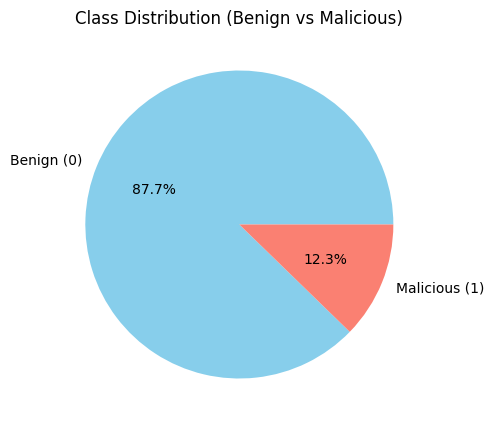

In [136]:
plt.figure(figsize=(5, 5))
plt.pie(class_counts, labels=labels, autopct='%1.1f%%', colors=["skyblue", "salmon"])
plt.title("Class Distribution (Benign vs Malicious)")
plt.show()

##### **2.7.3 Correlation Matrix between the Data**

In [137]:
df.corr()

,PACKET_TYPE,CONTROL_PACKET_TYPE/APP_NAME,SOURCE_ID,DESTINATION_ID,TRANSMITTER_ID,RECEIVER_ID,PHY_LAYER_ARRIVAL_TIME(US),PHY_LAYER_START_TIME(US),PHY_LAYER_END_TIME(US),NW_LAYER_PAYLOAD(Bytes),MAC_LAYER_PAYLOAD(Bytes),SOURCE_IP,DESTINATION_IP,GATEWAY_IP,NEXT_HOP_IP,PCKT_LABEL,RPL_RANK
PACKET_TYPE,1.000000,-0.881901,-0.283508,0.111195,-0.256756,-0.085897,-0.168748,-0.168748,-0.168748,0.996665,0.980556,0.229993,-0.599243,0.019292,-0.639698,-0.527382,NaN
CONTROL_PACKET_TYPE/APP_NAME,-0.881901,1.000000,0.505103,-0.224006,0.385329,0.091534,0.189369,0.189369,0.189369,-0.877360,-0.838767,-0.291746,0.588592,-0.087934,0.633348,0.573962,-0.823017
SOURCE_ID,-0.283508,0.505103,1.000000,-0.556670,0.848596,0.026462,0.222365,0.222365,0.222365,-0.284863,-0.180045,-0.444035,0.452620,-0.352939,0.469023,0.624437,-0.594385
DESTINATION_ID,0.111195,-0.224006,-0.556670,1.000000,-0.509160,0.069758,-0.258347,-0.258347,-0.258347,0.110514,-0.050878,0.376301,-0.574783,0.376297,-0.556868,-0.768823,0.615421
TRANSMITTER_ID,-0.256756,0.385329,0.848596,-0.509160,1.000000,0.022883,0.204679,0.204679,0.204679,-0.258048,-0.160293,-0.407886,0.425633,-0.305038,0.439416,0.578912,-0.594385
RECEIVER_ID,-0.085897,0.091534,0.026462,0.069758,0.022883,1.000000,0.033377,0.033377,0.033377,-0.085980,-0.074212,-0.137498,0.154114,-0.062569,0.162028,0.094665,-0.124772
PHY_LAYER_ARRIVAL_TIME(US),-0.168748,0.189369,0.222365,-0.258347,0.204679,0.033377,1.000000,1.000000,1.000000,-0.169766,-0.115179,-0.225534,0.269531,-0.184231,0.269620,0.350642,-0.274432
PHY_LAYER_START_TIME(US),-0.168748,0.189369,0.222365,-0.258347,0.204679,0.033377,1.000000,1.000000,1.000000,-0.169766,-0.115179,-0.225534,0.269531,-0.184231,0.269620,0.350642,-0.274432
PHY_LAYER_END_TIME(US),-0.168748,0.189369,0.222365,-0.258347,0.204679,0.033377,1.000000,1.000000,1.000000,-0.169766,-0.115179,-0.225534,0.269532,-0.184231,0.269621,0.350642,-0.274432
NW_LAYER_PAYLOAD(Bytes),0.996665,-0.877360,-0.284863,0.110514,-0.258048,-0.085980,-0.169766,-0.169766,-0.169766,1.000000,0.982666,0.225184,-0.605100,0.015284,-0.645712,-0.529838,NaN


##### **2.7.4 Correlation Heatmap the Data**

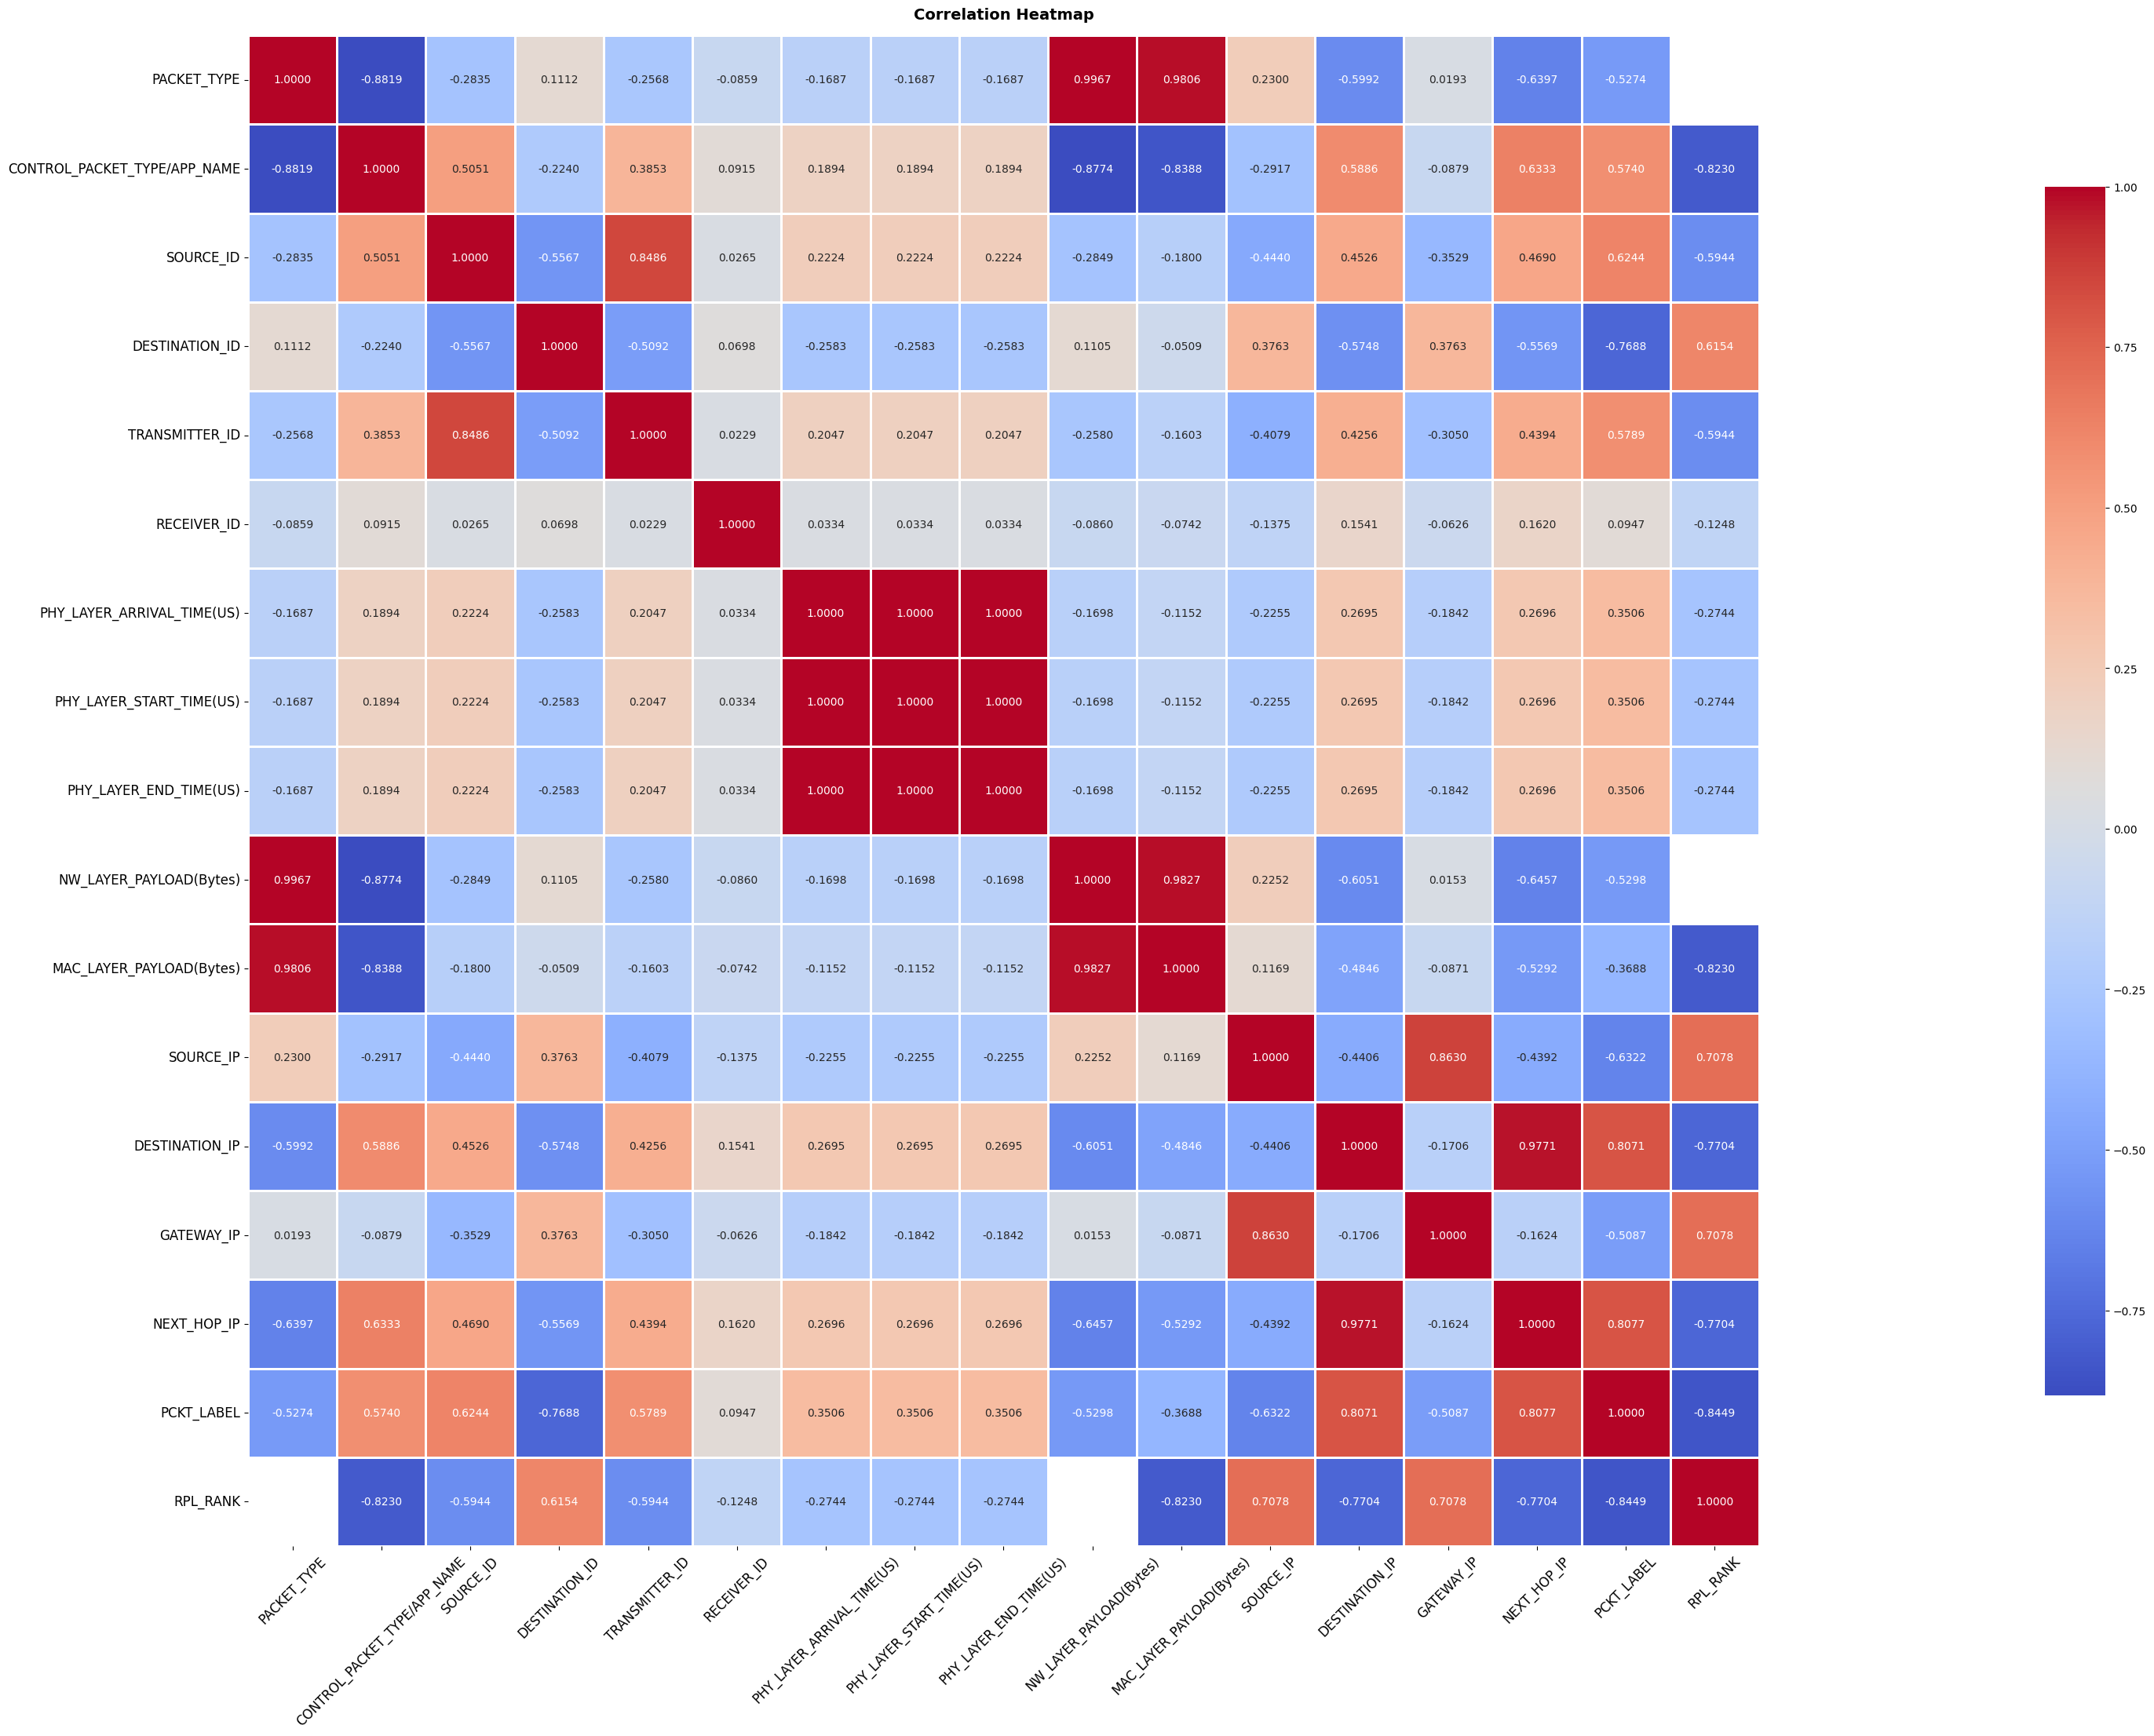

In [138]:
# Visualize correlation between features using a heatmap
# Check correlation and plot heatmap
plt.figure(figsize=(94, 25))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".4f", linewidths=2, square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap", fontsize=14, fontweight='bold', pad=15)
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12, rotation=0)
plt.show()

#### **2.8 Downsample Benign Class**

In [139]:
# Separate benign and malicious
malicious_df = df[df["PCKT_LABEL"] == 1]
benign_df = df[df["PCKT_LABEL"] == 0]

# Find the smaller class count
min_count = min(len(benign_df), len(malicious_df))

# Downsample both to the same size
benign_downsampled = benign_df.sample(n=min_count, random_state=42)
malicious_downsampled = malicious_df.sample(n=min_count, random_state=42)

# Combine and shuffle
balanced_df = pd.concat([benign_downsampled, malicious_downsampled], axis=0).sample(frac=1, random_state=42)

# Check balance
console.print("[bold green]Balanced class distribution (Manual Downsampling):[/bold green]")
console.print(balanced_df["PCKT_LABEL"].value_counts())

Balanced class distribution (Manual Downsampling):

PCKT_LABEL
1    110181
0    110181
Name: count, dtype: int64

#### **2.9 Feature Engineering**

##### **2.9.1 Feature Scaling using StandardScaler**

In [140]:
# Exclude label column from scaling (Separate features and target variable)
X = balanced_df.drop(columns=["PCKT_LABEL"])
y = balanced_df["PCKT_LABEL"]

# Apply StandardScaler
scaler = StandardScaler()                   # Initialize the scaler
X_scaled = scaler.fit_transform(X)          # Fit and transform the data                      

# Convert back to DataFrame (for column reference)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)  # Convert the scaled data back to DataFrame for easy viewing

# Print the scaled features
console.print(f"[bold green]Feature scaling completed using StandardScaler.[/bold green]")
console.print(f"[bold blue]Scaled Data Shape:[/bold blue] {X_scaled_df.shape}")

Feature scaling completed using StandardScaler.

Scaled Data Shape: (220362, 16)

In [141]:
console.print(f"[bold green]Scaled Feature Values:[/bold green]")
X_scaled_df.head()

Scaled Feature Values:

,PACKET_TYPE,CONTROL_PACKET_TYPE/APP_NAME,SOURCE_ID,DESTINATION_ID,TRANSMITTER_ID,RECEIVER_ID,PHY_LAYER_ARRIVAL_TIME(US),PHY_LAYER_START_TIME(US),PHY_LAYER_END_TIME(US),NW_LAYER_PAYLOAD(Bytes),MAC_LAYER_PAYLOAD(Bytes),SOURCE_IP,DESTINATION_IP,GATEWAY_IP,NEXT_HOP_IP,RPL_RANK
0,-0.424334,0.467710,0.516732,-0.672101,0.472419,0.306270,-0.218235,-0.218235,-0.218235,-0.426581,-0.286919,-0.524513,0.718145,-0.407367,0.718945,-0.653920
1,-0.424334,0.203916,0.254604,1.730586,0.231024,0.474987,0.502263,0.502263,0.502263,-0.426581,-0.634726,-0.035097,-1.103756,0.053570,-1.025242,0.905048
2,-0.424334,0.203916,-1.056035,2.451392,-0.975951,1.318577,0.326818,0.326818,0.326818,-0.426581,-0.634726,-1.258636,-0.062670,-1.098773,-0.028563,-0.542565
3,-0.424334,0.467710,0.516732,-0.672101,0.472419,-1.380909,1.458254,1.458254,1.458254,-0.426581,-0.286919,-0.524513,0.718145,-0.407367,0.718945,-0.653920
4,-0.424334,0.467710,0.516732,-0.672101,0.472419,0.981141,-0.494080,-0.494080,-0.494080,-0.426581,-0.286919,-0.524513,0.718145,-0.407367,0.718945,-0.653920


### **3. Model Building, Implementation and Evaluation**

#### **3.1 Imputing NaN Values**

In [142]:
# Impute remaining NaNs with column means (recommended for numeric features)
X_scaled_df.fillna(X_scaled_df.mean(), inplace=True)

console.print("[bold green]NaN values filled using column mean.[/bold green]")
console.print(f"[bold blue]New shape after imputation:[/bold blue] {X_scaled_df.shape}")

NaN values filled using column mean.

New shape after imputation: (220362, 16)

#### **3.2 Data Splitting using Test-Train Split**

In [143]:
# Stratified split after downsampling
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.3, random_state=42, stratify=y)

console.print("[bold green]Train-test split completed.[/bold green]")
console.print(f"[bold blue]Training Set:[/bold blue] {X_train.shape[0]} samples",
              f"\n[bold blue]Testing Set :[/bold blue] {X_test.shape[0]} samples")

Train-test split completed.

Training Set: 154253 samples 
Testing Set : 66109 samples

#### **3.3 Helper Function for Model Evaluation**

In [144]:
# Helper to evaluate model - Notebook 4 (Manual Downsampling)
def evaluate_model(model, model_name, X_test, y_test, y_pred):
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    console.print(f"[bold]{model_name} Evaluation (Manual Downsampling)[/bold]",
                  f"\n[bold]Accuracy :[/bold] {acc:.4f}",
                  f"\n[bold]Precision:[/bold] {prec:.4f}",
                  f"\n[bold]Recall   :[/bold] {rec:.4f}",
                  f"\n[bold]F1 Score :[/bold] {f1:.4f}")

    # Confusion Matrix
    plt.figure(figsize=(4, 3))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    # First 10 random predictions
    sample_idx = np.random.choice(len(y_test), size=10, replace=False)
    comparison_df = pd.DataFrame({
        'Actual': y_test.values[sample_idx],
        'Predicted': y_pred[sample_idx]
    })
    console.print(f"[bold]Random 10 Predictions - {model_name}[/bold]")
    console.print(comparison_df)


#### **3.4 Model Implementation**

##### **3.4.1 Linear Regression**

Logistic Regression (Manual Downsampling) Evaluation (Manual Downsampling) 
Accuracy : 0.9995 
Precision: 0.9990 
Recall   : 1.0000 
F1 Score : 0.9995

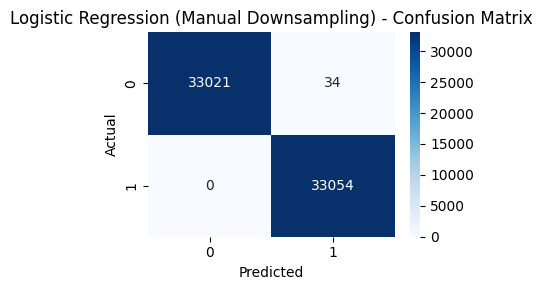

Random 10 Predictions - Logistic Regression (Manual Downsampling)

Actual  Predicted
0       1          1
1       1          1
2       0          0
3       0          0
4       0          0
5       1          1
6       0          0
7       0          0
8       0          0
9       0          0

In [145]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

evaluate_model(lr_model,"Logistic Regression (Manual Downsampling)",X_test, y_test, y_pred_lr)

##### **3.4.2 Random Forest**

Random Forest Classifier (Manual Downsampling) Evaluation (Manual Downsampling) 
Accuracy : 1.0000 
Precision: 1.0000 
Recall   : 1.0000 
F1 Score : 1.0000

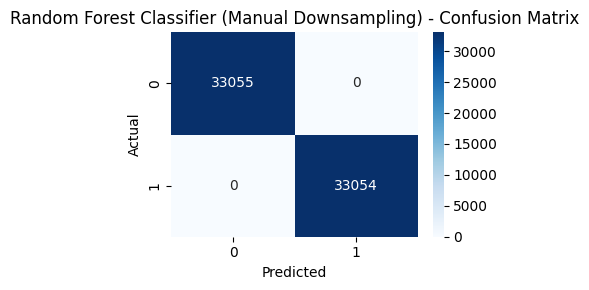

Random 10 Predictions - Random Forest Classifier (Manual Downsampling)

Actual  Predicted
0       1          1
1       0          0
2       0          0
3       0          0
4       0          0
5       0          0
6       1          1
7       0          0
8       1          1
9       1          1

In [146]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

evaluate_model(rf_model,"Random Forest Classifier (Manual Downsampling)",X_test, y_test, y_pred_rf)

##### **3.4.3 MLP (Neural Network)**

Neural Network - MLP (Manual Downsampling) Evaluation (Manual Downsampling) 
Accuracy : 1.0000 
Precision: 1.0000 
Recall   : 1.0000 
F1 Score : 1.0000

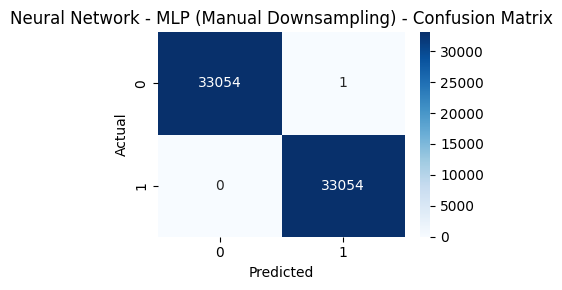

Random 10 Predictions - Neural Network - MLP (Manual Downsampling)

Actual  Predicted
0       1          1
1       0          0
2       1          1
3       1          1
4       1          1
5       0          0
6       0          0
7       0          0
8       0          0
9       0          0

In [147]:
mlp_model = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', max_iter=300, random_state=42)
mlp_model.fit(X_train, y_train)
y_pred_mlp = mlp_model.predict(X_test)

evaluate_model(mlp_model,"Neural Network - MLP (Manual Downsampling)",X_test, y_test, y_pred_mlp)

##### **3.4.4 LSTM (Long-Short Term Memory)**

In [148]:
# ============================================================================================================
# Step 1: Prepare Sequential Data
# ============================================================================================================

# Reset index to ensure alignment by position
X_scaled_df = X_scaled_df.reset_index(drop=True)
y = y.reset_index(drop=True)

# Now safe to create sequences
def create_lstm_sequences(X, y, window_size=10):
    X_seq, y_seq = [], []
    for i in range(len(X) - window_size):
        X_seq.append(X[i:i+window_size].values)
        y_seq.append(y[i+window_size])
    return np.array(X_seq), np.array(y_seq)

X_lstm, y_lstm = create_lstm_sequences(X_scaled_df, y, window_size=10)

# Convert to tensors
X_tensor = torch.tensor(X_lstm, dtype=torch.float32)
y_tensor = torch.tensor(y_lstm, dtype=torch.float32)

In [149]:
# ============================================================================================================
# Step 2: Train-Test Split for Sequences
# ============================================================================================================

# Train-test split (70/30 on sequence data)
train_size = int(0.7 * len(X_tensor))
test_size = len(X_tensor) - train_size

train_dataset, test_dataset = random_split(TensorDataset(X_tensor, y_tensor), [train_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

In [150]:
# ============================================================================================================
# Step 3: Define the LSTM Model
# ============================================================================================================

class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super(LSTMClassifier, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return self.sigmoid(out)

input_size = X_scaled_df.shape[1]
model = LSTMClassifier(input_size=input_size, hidden_size=64, num_layers=2)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [151]:
# ============================================================================================================
# Step 4: Train the LSTM Model
# ============================================================================================================

model.train()
epochs = 5
loss_history = []

for epoch in range(epochs):
    epoch_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        output = model(batch_x).squeeze()
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)
    console.print(f"[bold green]LSTM Epoch {epoch+1}/{epochs}, LSTM Loss: {avg_loss:.4f}[/bold green]")

LSTM Epoch 1/5, LSTM Loss: 0.6933

LSTM Epoch 2/5, LSTM Loss: 0.6932

LSTM Epoch 3/5, LSTM Loss: 0.6932

LSTM Epoch 4/5, LSTM Loss: 0.6931

LSTM Epoch 5/5, LSTM Loss: 0.6930

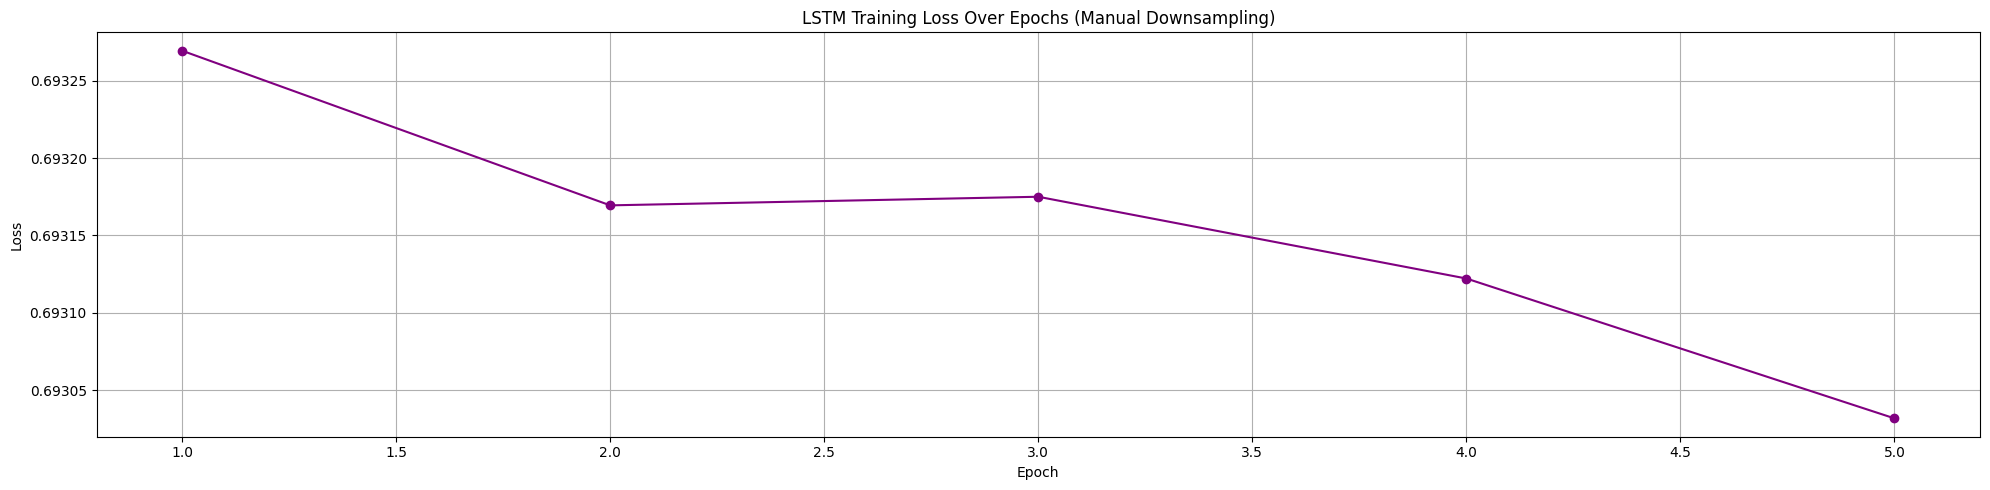

In [152]:
# ============================================================================================================
# Step 5: Plot Training Loss
# ============================================================================================================

plt.figure(figsize=(20, 5))
plt.plot(range(1, epochs + 1), loss_history, marker='o', linestyle='-', color='purple')
plt.title("LSTM Training Loss Over Epochs (Manual Downsampling)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

Long Short-Term Memory - LSTM (Manual Downsampling) Evaluation (Manual Downsampling) 
Accuracy : 0.4988 
Precision: 0.4968 
Recall   : 0.6815 
F1 Score : 0.5747

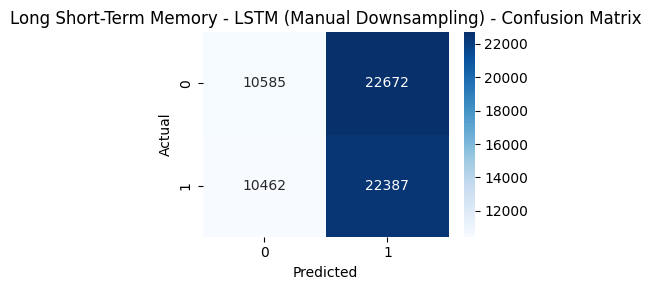

Random 10 Predictions - Long Short-Term Memory - LSTM (Manual Downsampling)

Actual  Predicted
28633       1          0
21643       0          0
41791       0          0
43539       0          1
31668       1          1
28494       0          1
57065       1          1
11458       1          1
47279       0          1
35138       0          1

In [153]:
# ============================================================================================================
# Step 6: Predict and Evaluate
# ============================================================================================================

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        output = model(batch_x).squeeze()
        preds = (output > 0.5).float()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

# Convert to pandas Series for compatibility
y_pred_series = pd.Series(np.array(all_preds).astype(int))
y_test_series = pd.Series(np.array(all_labels).astype(int))

# Evaluate using shared helper
evaluate_model(model=None, model_name="Long Short-Term Memory - LSTM (Manual Downsampling)", X_test=None, y_test=y_test_series, y_pred=y_pred_series)

##### **3.5.5 GRU (Gated Recurrent Units)**

In [154]:
# ============================================================================================================
# Step 1: Prepare Sequential Data Apply Train-Test Split
# ============================================================================================================

def create_gru_sequences(X, y, window_size=10):
    X_seq, y_seq = [], []
    for i in range(len(X) - window_size):
        X_seq.append(X[i:i+window_size].values)
        y_seq.append(y[i+window_size])
    return np.array(X_seq), np.array(y_seq)

X_gru, y_gru = create_gru_sequences(X_scaled_df, y, window_size=10)

X_tensor_gru = torch.tensor(X_gru, dtype=torch.float32)
y_tensor_gru = torch.tensor(y_gru, dtype=torch.float32)

In [155]:
# ============================================================================================================
# Step 2: Apply Train-Test Split
# ============================================================================================================

train_size_gru = int(0.7 * len(X_tensor_gru))
test_size_gru = len(X_tensor_gru) - train_size_gru

train_dataset_gru, test_dataset_gru = random_split(
    TensorDataset(X_tensor_gru, y_tensor_gru),
    [train_size_gru, test_size_gru]
)

train_loader_gru = DataLoader(train_dataset_gru, batch_size=64, shuffle=True)
test_loader_gru = DataLoader(test_dataset_gru, batch_size=64)

In [156]:
# ============================================================================================================
# Step 3: Define the GRU Model
# ============================================================================================================

class GRUClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super(GRUClassifier, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return self.sigmoid(out)

input_size = X_scaled_df.shape[1]
gru_model = GRUClassifier(input_size=input_size, hidden_size=64, num_layers=2)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(gru_model.parameters(), lr=0.001)

In [157]:
# ============================================================================================================
# Step 4: Train GRU Model
# ============================================================================================================

gru_model.train()
epochs = 5
loss_history_gru = []

for epoch in range(epochs):
    epoch_loss = 0
    for batch_x, batch_y in train_loader_gru:
        optimizer.zero_grad()
        output = gru_model(batch_x).squeeze()
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader_gru)
    loss_history_gru.append(avg_loss)
    console.print(f"[bold green]GRU Epoch {epoch+1}/{epochs}, GRU Loss: {avg_loss:.4f}[/bold green]")

GRU Epoch 1/5, GRU Loss: 0.6934

GRU Epoch 2/5, GRU Loss: 0.6932

GRU Epoch 3/5, GRU Loss: 0.6932

GRU Epoch 4/5, GRU Loss: 0.6932

GRU Epoch 5/5, GRU Loss: 0.6932

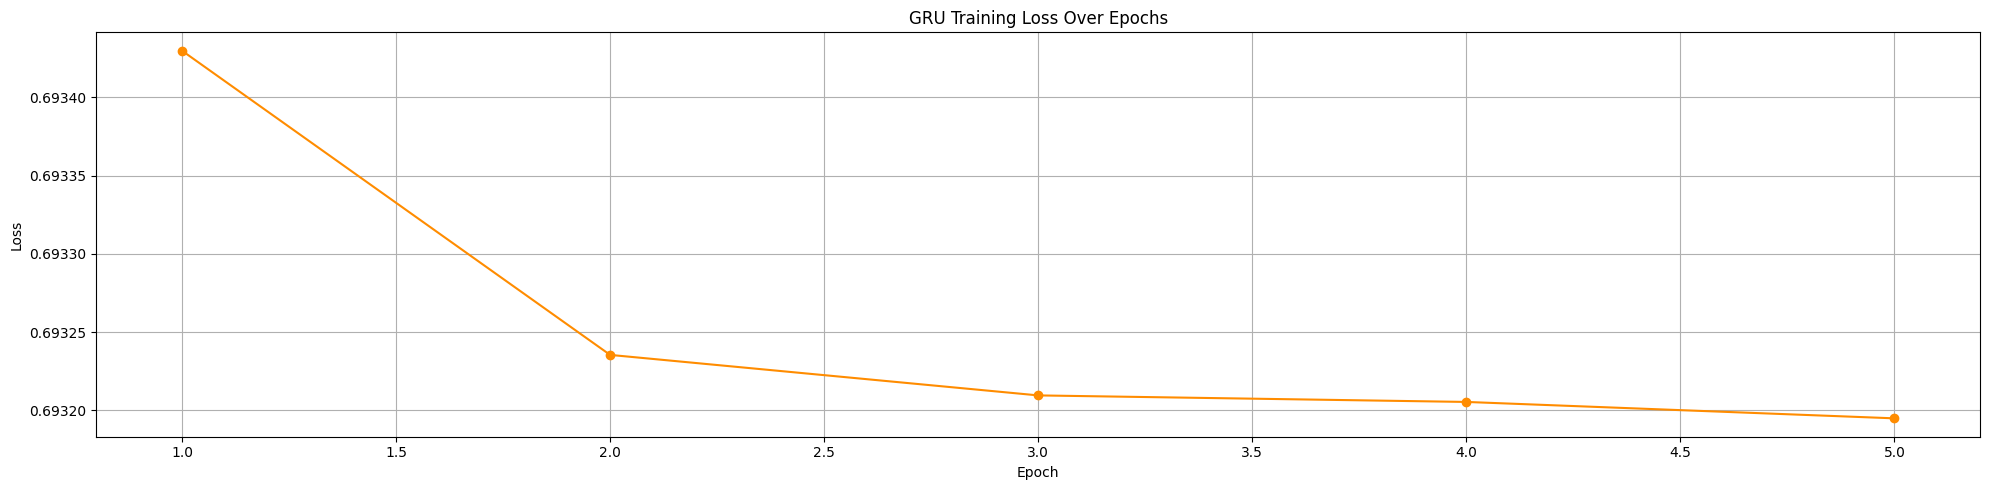

In [158]:
# ============================================================================================================
# Step 5: Plot Training Loss
# ============================================================================================================

plt.figure(figsize=(20, 5))
plt.plot(range(1, epochs + 1), loss_history_gru, marker='o', linestyle='-', color='darkorange')
plt.title("GRU Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

GRU Classifier (Manual Downsampling) Evaluation (Manual Downsampling) 
Accuracy : 0.4984 
Precision: 0.4987 
Recall   : 0.8027 
F1 Score : 0.6152

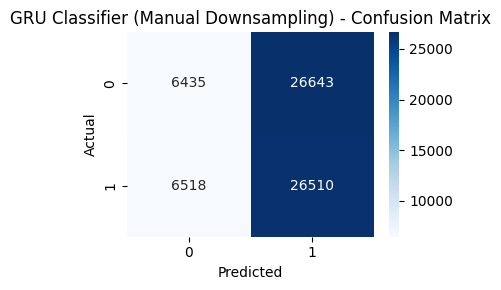

Random 10 Predictions - GRU Classifier (Manual Downsampling)

Actual  Predicted
22864       1          1
63545       0          1
58643       0          0
26456       1          1
6442        1          1
22457       0          1
51525       0          1
31409       1          0
14779       0          1
65739       1          1

In [159]:
# ============================================================================================================
# Step 6: Evaluate GRU Model
# ============================================================================================================

gru_model.eval()
all_preds_gru = []
all_labels_gru = []

with torch.no_grad():
    for batch_x, batch_y in test_loader_gru:
        output = gru_model(batch_x).squeeze()
        preds = (output > 0.5).float()
        all_preds_gru.extend(preds.cpu().numpy())
        all_labels_gru.extend(batch_y.cpu().numpy())

# Convert to Pandas Series
y_pred_gru = pd.Series(np.array(all_preds_gru).astype(int))
y_test_gru = pd.Series(np.array(all_labels_gru).astype(int))

evaluate_model(model=None, model_name="GRU Classifier (Manual Downsampling)", X_test=None, y_test=y_test_gru, y_pred=y_pred_gru)

##### **3.5.6 Isolation Forest**

In [160]:
# ============================================================================================================
# Step 1: Filter benign samples for training
# ============================================================================================================

X_benign = X_scaled_df[y == 0]
X_full = X_scaled_df
y_true = y.reset_index(drop=True)

In [161]:
# ============================================================================================================
# Step 2: Fit Isolation Forest on benign data only
# ============================================================================================================

iso_model = IsolationForest(n_estimators=100, contamination="auto", random_state=42)
iso_model.fit(X_benign)

IsolationForest(random_state=42)

In [162]:
# ============================================================================================================
# Step 3: Predict on full dataset
# ============================================================================================================

predictions = iso_model.predict(X_full)
# IsolationForest outputs: 1 = normal, -1 = anomaly → convert to: 0 = benign, 1 = attack
y_pred_iso = pd.Series((predictions == -1).astype(int))

Isolation Forest (Benign Only Training) Evaluation (Manual Downsampling) 
Accuracy : 0.7367 
Precision: 0.6551 
Recall   : 1.0000 
F1 Score : 0.7916

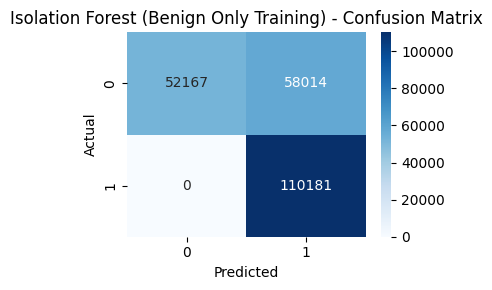

Random 10 Predictions - Isolation Forest (Benign Only Training)

Actual  Predicted
142427       0          1
94517        0          0
49196        1          1
73838        1          1
209132       0          0
143732       1          1
73280        1          1
130543       1          1
105287       1          1
186639       0          1

In [163]:
# ============================================================================================================
# Step 4: Evaluate Isolation Forest Model
# ============================================================================================================

evaluate_model(model=None, model_name="Isolation Forest (Benign Only Training)", X_test=None, y_test=y_true, y_pred=y_pred_iso)

### **4. Model Performance Comparison**

#### **4.1 Tabular Summary of All Metrics**

In [164]:
# Model performance data
metrics = {
    "Logistic Regression":  [accuracy_score(y_test, y_pred_lr), precision_score(y_test, y_pred_lr),
                             recall_score(y_test, y_pred_lr), f1_score(y_test, y_pred_lr)],

    "Random Forest":        [accuracy_score(y_test, y_pred_rf), precision_score(y_test, y_pred_rf),
                             recall_score(y_test, y_pred_rf), f1_score(y_test, y_pred_rf)],

    "MLP Neural Net":       [accuracy_score(y_test, y_pred_mlp), precision_score(y_test, y_pred_mlp),
                             recall_score(y_test, y_pred_mlp), f1_score(y_test, y_pred_mlp)],

    "LSTM":                 [accuracy_score(y_test_series, y_pred_series),
                             precision_score(y_test_series, y_pred_series),
                             recall_score(y_test_series, y_pred_series),
                             f1_score(y_test_series, y_pred_series)],

    "GRU":                  [accuracy_score(y_test_gru, y_pred_gru),
                             precision_score(y_test_gru, y_pred_gru),
                             recall_score(y_test_gru, y_pred_gru),
                             f1_score(y_test_gru, y_pred_gru)],
    
    "Isolation Forest":     [accuracy_score(y_true, y_pred_iso),
                             precision_score(y_true, y_pred_iso),
                             recall_score(y_true, y_pred_iso),
                             f1_score(y_true, y_pred_iso)]
}

comparison_df = pd.DataFrame(metrics, index=["Accuracy", "Precision", "Recall", "F1 Score"]).T
comparison_df = comparison_df.round(4)

console.print("[bold green]Model Performance Comparison (Manual Downsampling)[/bold green]")
console.print(comparison_df)


Model Performance Comparison (Manual Downsampling)

Accuracy  Precision  Recall  F1 Score
Logistic Regression    0.9995     0.9990  1.0000    0.9995
Random Forest          1.0000     1.0000  1.0000    1.0000
MLP Neural Net         1.0000     1.0000  1.0000    1.0000
LSTM                   0.4988     0.4968  0.6815    0.5747
GRU                    0.4984     0.4987  0.8027    0.6152
Isolation Forest       0.7367     0.6551  1.0000    0.7916

#### **4.2 Barplot for All Metrics**

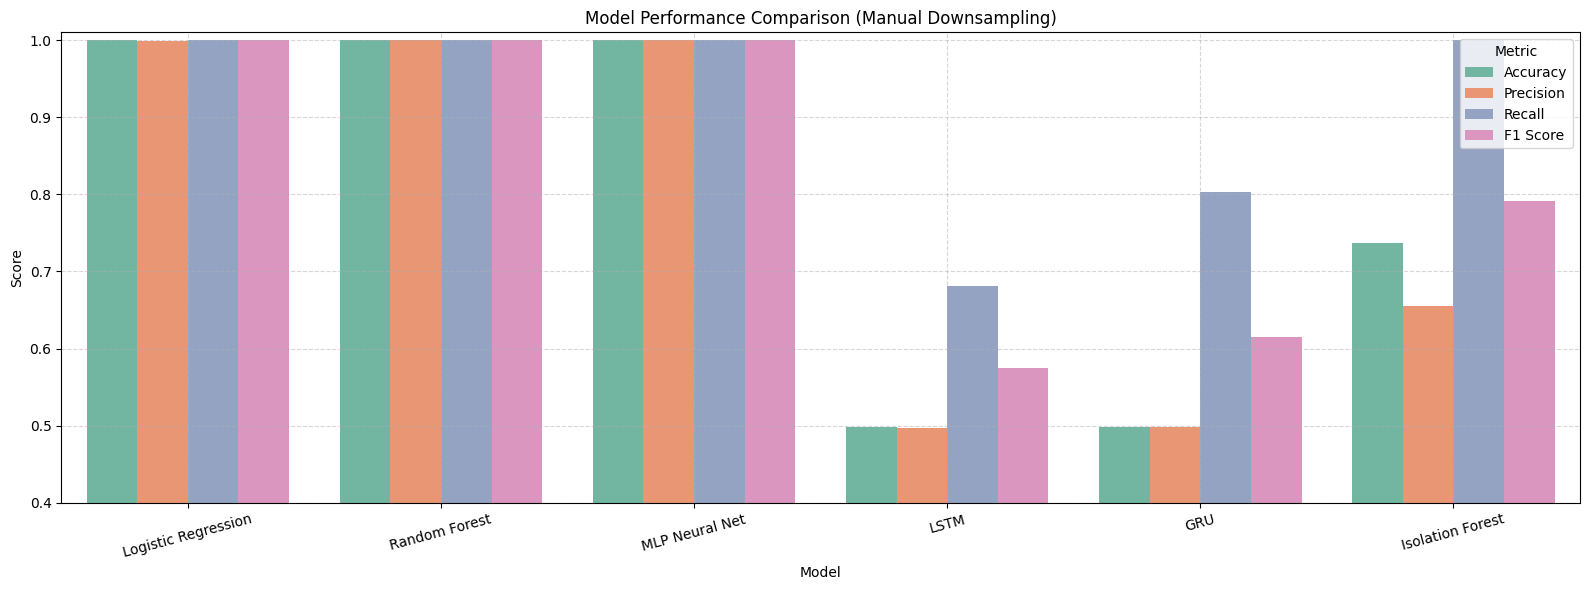

In [165]:
melted_df = comparison_df.reset_index().melt(id_vars="index", var_name="Metric", value_name="Score")
melted_df.rename(columns={"index": "Model"}, inplace=True)

plt.figure(figsize=(16, 6))
sns.barplot(data=melted_df, x="Model", y="Score", hue="Metric", palette="Set2")
plt.title("Model Performance Comparison (Manual Downsampling)")
plt.ylabel("Score")
plt.ylim(0.40, 1.01)
plt.xticks(rotation=15)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

#### **4.3 Slope Graph for F1 Score**

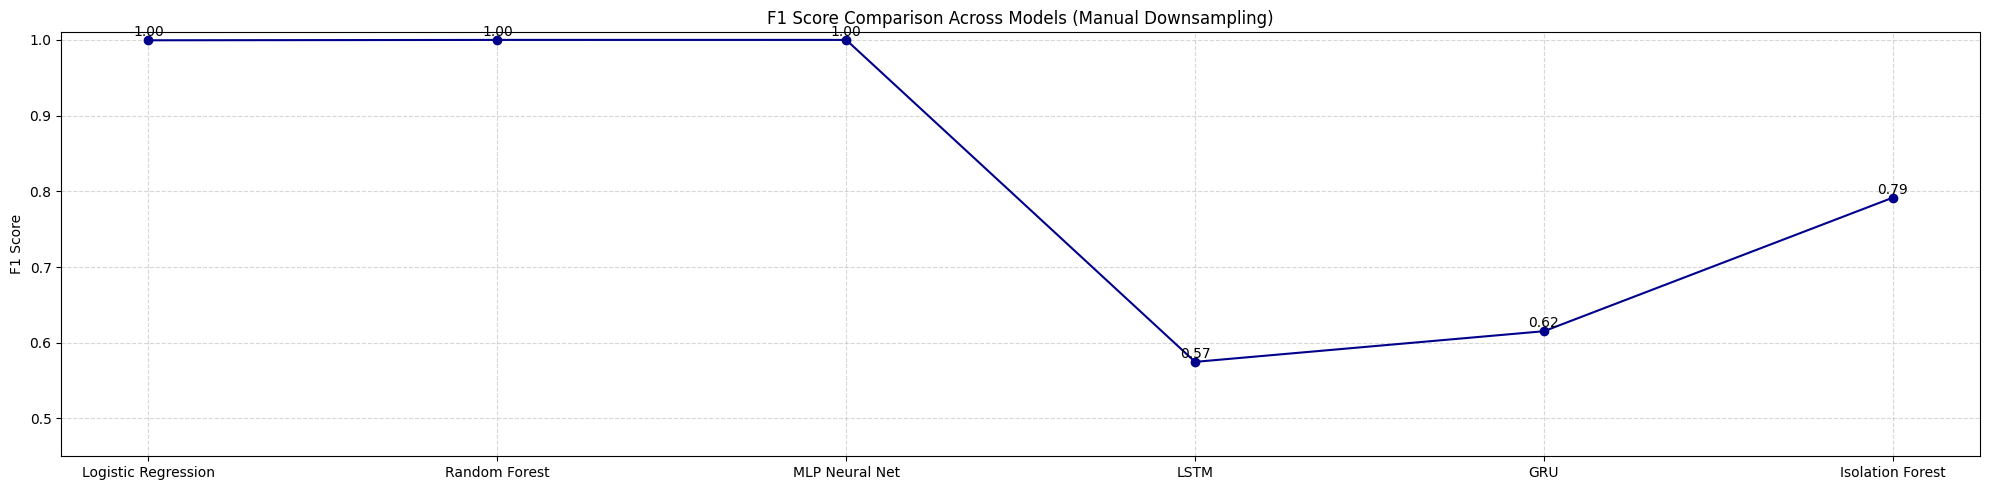

In [166]:
plt.figure(figsize=(20, 5))
plt.plot(comparison_df.index, comparison_df["F1 Score"], marker='o', linestyle='-', color='darkblue')

for i, score in enumerate(comparison_df["F1 Score"]):
    plt.text(i, score + 0.005, f"{score:.2f}", ha='center')

plt.title("F1 Score Comparison Across Models (Manual Downsampling)")
plt.ylabel("F1 Score")
plt.ylim(0.45, 1.01)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### **5. Exporting Results**

#### **5.1 Model metrics for LR, RF, MLP, LSTM, GRU and Isolation Model**

In [167]:
comparison_df.to_csv("6_results_notebook4.csv") 

#### **5.2 Confusion Matrices**

In [168]:
confusion_dict = {
    "LR": confusion_matrix(y_test, y_pred_lr),
    "RF": confusion_matrix(y_test, y_pred_rf),
    "MLP": confusion_matrix(y_test, y_pred_mlp),
    "LSTM": confusion_matrix(y_test_series, y_pred_series),
    "GRU": confusion_matrix(y_test_gru, y_pred_gru),
    "ISO": confusion_matrix(y_true, y_pred_iso)
}

with open("7_confusion_notebook4.pkl", "wb") as f:
    pickle.dump(confusion_dict, f)